<a href="https://colab.research.google.com/github/manaswinidoma/iot-network-security-analysis/blob/main/iot_network_security_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.svm import SVC
from random import seed
from random import randrange
from sklearn.model_selection import KFold
kf = KFold(n_splits=5)
import csv
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Binarizer
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.neural_network import MLPClassifier

# **DATA** **PREPROCESSING**

In [ ]:
dataset = pd.read_csv('train_IoT_Intrusion_Detection.csv')

In [ ]:
print(dataset.shape)
dataset.describe()
print(dataset.dtypes)

(15600, 48)
Unnamed: 0           int64
flow_duration      float64
Header_Length      float64
Protocol Type      float64
Duration           float64
Rate               float64
Srate              float64
Drate              float64
fin_flag_number      int64
syn_flag_number      int64
rst_flag_number      int64
psh_flag_number      int64
ack_flag_number      int64
ece_flag_number      int64
cwr_flag_number      int64
ack_count          float64
syn_count          float64
fin_count          float64
urg_count          float64
rst_count          float64
HTTP                 int64
HTTPS                int64
DNS                  int64
Telnet               int64
SMTP                 int64
SSH                  int64
IRC                  int64
TCP                  int64
UDP                  int64
DHCP                 int64
ARP                  int64
ICMP                 int64
IPv                  int64
LLC                  int64
Tot sum            float64
Min                float64
Max             

In [ ]:
missing_values = dataset.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 Unnamed: 0         0
flow_duration      0
Header_Length      0
Protocol Type      0
Duration           0
Rate               0
Srate              0
Drate              0
fin_flag_number    0
syn_flag_number    0
rst_flag_number    0
psh_flag_number    0
ack_flag_number    0
ece_flag_number    0
cwr_flag_number    0
ack_count          0
syn_count          0
fin_count          0
urg_count          0
rst_count          0
HTTP               0
HTTPS              0
DNS                0
Telnet             0
SMTP               0
SSH                0
IRC                0
TCP                0
UDP                0
DHCP               0
ARP                0
ICMP               0
IPv                0
LLC                0
Tot sum            0
Min                0
Max                0
AVG                0
Std                0
Tot size           0
IAT                0
Number             0
Magnitue           0
Radius             0
Covariance         0
Variance           0
We

In [ ]:
print(dataset['label'].value_counts())

label
Mirai-greip_flood       13561
Recon-OSScan             1780
DictionaryBruteForce      259
Name: count, dtype: int64


In [ ]:
# Select only the columns that are categorical or binary
categorical_columns = dataset.select_dtypes(include=['object', 'int64', 'float64']).columns

# Function to count occurrences of 0 and 1 for each column
def count_zero_one(dataset, columns):
    count_df = pd.DataFrame()

    for col in columns:
        if dataset[col].isin([0, 1]).all():  # Check if column contains only 0s and 1s
            count_0 = (dataset[col] == 0).sum()  # Count of 0s
            count_1 = (dataset[col] == 1).sum()  # Count of 1s
            count_df.loc[col, 'Count of 0s'] = count_0
            count_df.loc[col, 'Count of 1s'] = count_1
        else:
            count_df.loc[col, 'Count of 0s'] = "N/A"
            count_df.loc[col, 'Count of 1s'] = "N/A"

    return count_df

# Apply the function to count 0s and 1s in categorical columns
zero_one_counts = count_zero_one(dataset, categorical_columns)

# Display the result
print(zero_one_counts)

                Count of 0s Count of 1s
Unnamed: 0              N/A         N/A
flow_duration           N/A         N/A
Header_Length           N/A         N/A
Protocol Type           N/A         N/A
Duration                N/A         N/A
Rate                    N/A         N/A
Srate                   N/A         N/A
Drate                 15600           0
fin_flag_number       15596           4
syn_flag_number       15395         205
rst_flag_number       15454         146
psh_flag_number       15537          63
ack_flag_number       14102        1498
ece_flag_number       15600           0
cwr_flag_number       15600           0
ack_count               N/A         N/A
syn_count               N/A         N/A
fin_count               N/A         N/A
urg_count               N/A         N/A
rst_count               N/A         N/A
HTTP                  15530          70
HTTPS                 14816         784
DNS                   15578          22
Telnet                15600           0


In [ ]:
new_dataset = dataset.drop(['Unnamed: 0','Drate','Srate','fin_flag_number', 'ece_flag_number', 'cwr_flag_number', 'Telnet', 'SMTP', 'IRC','DNS', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'HTTP', 'SSH'], axis=1) #Removing the mentioned columns as they are not necessary
dataset_2 = dataset.drop(['Unnamed: 0','Drate','Srate','fin_flag_number', 'ece_flag_number', 'cwr_flag_number', 'Telnet', 'SMTP', 'IRC','DNS', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'HTTP', 'SSH'], axis=1) #Removing the mentioned columns as they are not necessary
new_dataset.describe()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ack_count,...,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight
count,15600.000000,1.560000e+04,15600.000000,15600.000000,1.560000e+04,15600.000000,15600.000000,15600.000000,15600.000000,15600.000000,...,15600.000000,15600.000000,15600.000000,1.560000e+04,15600.000000,15600.000000,15600.000000,1.560000e+04,15600.000000,15600.000000
mean,58.735890,2.384301e+04,40.488088,69.431394,9.517368e+03,0.013141,0.009359,0.004038,0.096026,0.021197,...,533.241031,53.537958,532.570516,8.334004e+07,9.486565,31.849904,75.617553,3.891505e+04,0.220929,141.203367
std,1056.987013,1.818260e+05,13.525687,19.839338,1.040724e+05,0.113882,0.096291,0.063422,0.294636,0.119321,...,199.264840,168.473194,196.501891,3.022726e+07,1.452425,6.806265,238.274419,2.807570e+05,0.301429,37.366598
min,0.000000,0.000000e+00,1.570000,2.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,53.732491,0.000000,54.000000,0.000000e+00,1.000000,10.366429,0.000000,0.000000e+00,0.000000,1.000000
25%,0.000000,0.000000e+00,44.890000,64.000000,2.911201e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,558.726554,0.000000,559.560000,8.358152e+07,9.500000,33.355981,0.000000,0.000000e+00,0.000000,141.550000
50%,0.000000,7.800000e-01,46.530000,64.000000,1.277519e+01,0.000000,0.000000,0.000000,0.000000,0.000000,...,575.006673,12.341348,572.820000,8.364672e+07,9.500000,33.909245,17.239750,1.302436e+03,0.110000,141.550000
75%,0.029531,1.561250e+01,47.000000,65.910000,4.423948e+01,0.000000,0.000000,0.000000,0.000000,0.000000,...,578.000000,38.181881,578.000000,8.365092e+07,9.500000,34.000000,53.947396,5.706416e+03,0.280000,141.550000
max,51182.926770,8.879658e+06,47.000000,255.000000,2.097152e+06,1.000000,1.000000,1.000000,1.000000,2.900000,...,4099.559246,3439.690409,3850.000000,1.666019e+08,13.500000,89.884119,4864.456827,1.334536e+07,1.000000,244.600000


### **Equi-depth binning for Duration**

Number of bins (Doane's Rule): 22
Number of bins (Sturges' Rule): 15


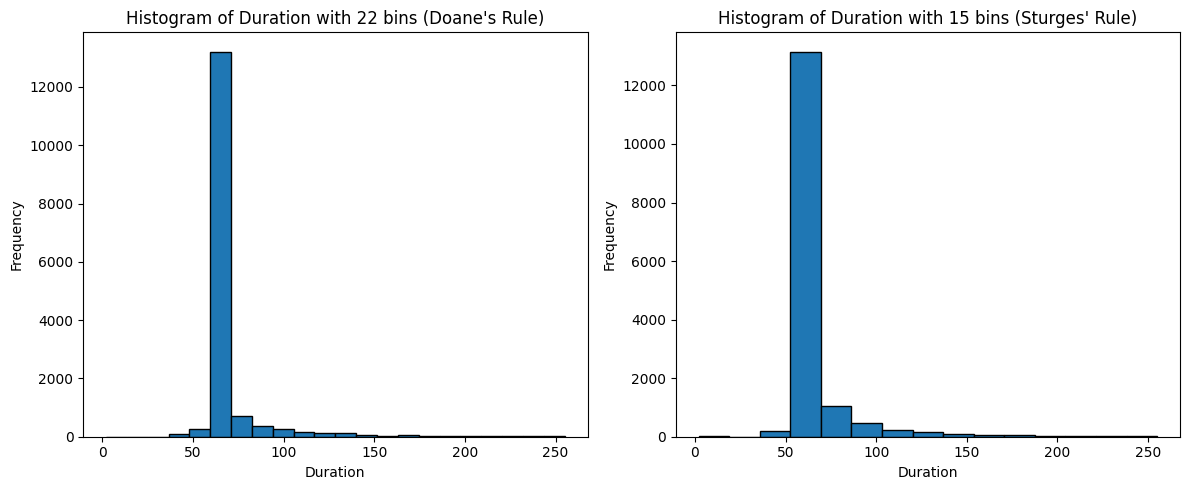

       Duration Binned_Equi_Depth_Duration
6641        2.0             (1.999, 62.72]
14955       2.0             (1.999, 62.72]
13935       2.0             (1.999, 62.72]
9048        7.8             (1.999, 62.72]
1000        7.8             (1.999, 62.72]
...         ...                        ...
1848      255.0            (90.693, 255.0]
14080     255.0            (90.693, 255.0]
7632      255.0            (90.693, 255.0]
5798      255.0            (90.693, 255.0]
3584      255.0            (90.693, 255.0]

[15600 rows x 2 columns]
                            Duration
Binned_Equi_Depth_Duration          
(1.999, 62.72]                  1105
(62.72, 63.36]                  1485
(63.36, 63.85]                   535
(63.85, 64.0]                   6712
(64.0, 64.64]                    646
(64.64, 65.72]                   963
(65.72, 66.54]                  1061
(66.54, 70.37]                  1016
(70.37, 90.693]                 1037
(90.693, 255.0]                 1040


In [ ]:
# Select the column of interest, e.g., 'Duration'
data = new_dataset['Duration']

# Calculating number of bins using Doane's Rule
skewness = skew(data)     # Calculate skewness of the dataset
n = len(data)             # Number of data points
sigma_g = np.sqrt(6 / n)  # Standard error of skewness
num_bins_doane = int(1 + np.log2(n) + np.log2(1 + (skewness / sigma_g)))  # Doane's Rule
print(f"Number of bins (Doane's Rule): {num_bins_doane}")

# Calculating number of bins using Sturges' Rule
def sturges_rule(data):
    n = len(data)
    return int(np.ceil(np.log2(n) + 1))  # Sturges' Rule

num_bins_sturges = sturges_rule(data)
print(f"Number of bins (Sturges' Rule): {num_bins_sturges}")

# Create subplots for side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot histogram using Doane's Rule
axes[0].hist(data, bins=num_bins_doane, edgecolor='black')
axes[0].set_title(f"Histogram of Duration with {num_bins_doane} bins (Doane's Rule)")
axes[0].set_xlabel('Duration')
axes[0].set_ylabel('Frequency')

# Plot histogram using Sturges' Rule
axes[1].hist(data, bins=num_bins_sturges, edgecolor='black')
axes[1].set_title(f"Histogram of Duration with {num_bins_sturges} bins (Sturges' Rule)")
axes[1].set_xlabel('Duration')
axes[1].set_ylabel('Frequency')

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plots
plt.show()

#Equi-Depth Binning Technique for Duration
num_bins_depth = 15 #number of bins for Equi Depth Binning

new_dataset['Binned_Equi_Depth_Duration'] = pd.qcut(data, q=num_bins_depth,duplicates='drop')


print(new_dataset[['Duration', 'Binned_Equi_Depth_Duration']].sort_values('Duration'))

freq_equi_depth = new_dataset[['Duration', 'Binned_Equi_Depth_Duration']].sort_values('Duration').groupby('Binned_Equi_Depth_Duration',observed=True).count()
print(new_dataset[['Duration', 'Binned_Equi_Depth_Duration']].sort_values('Duration').groupby('Binned_Equi_Depth_Duration', observed=True).count())

with pd.ExcelWriter('binned_duration.xlsx') as writer:
    # Save the DataFrame with binned data
    new_dataset.to_excel(writer, sheet_name='Binned Data', index=False)

    # Save frequencies for Equi-Depth Binning
    freq_equi_depth.reset_index().to_excel(writer, sheet_name='Equi-Depth Frequencies', index=False)


### **Equi-depth binning for Protocol Type**

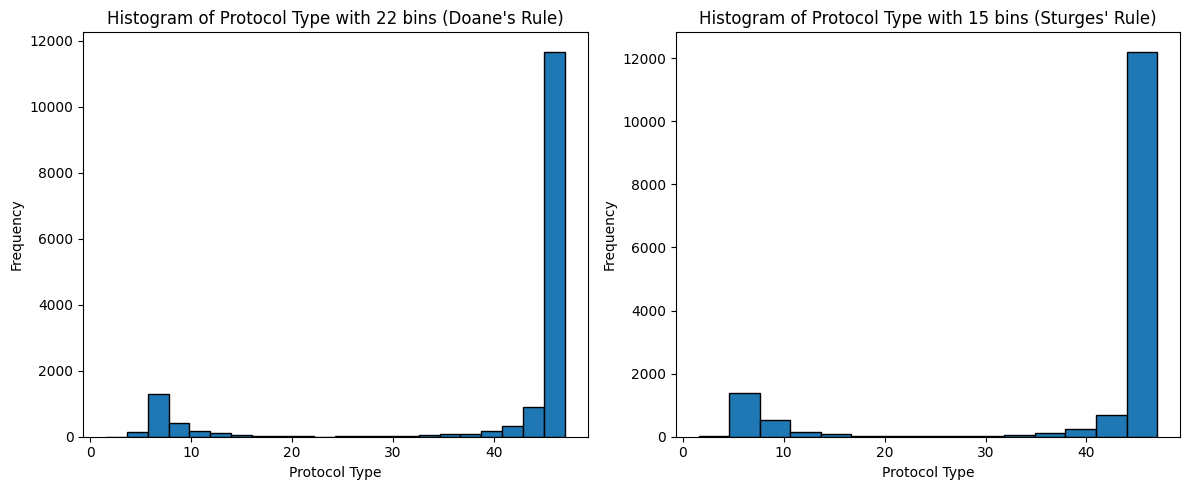

       Protocol Type Binned_Equi_Depth_Protocol_Type
1601            1.57       (1.5690000000000002, 6.5]
13016           1.80       (1.5690000000000002, 6.5]
2926            3.20       (1.5690000000000002, 6.5]
9394            3.20       (1.5690000000000002, 6.5]
10128           3.60       (1.5690000000000002, 6.5]
...              ...                             ...
11642          47.00                   (46.59, 47.0]
7513           47.00                   (46.59, 47.0]
2474           47.00                   (46.59, 47.0]
3027           47.00                   (46.59, 47.0]
6080           47.00                   (46.59, 47.0]

[15600 rows x 2 columns]
                                 Protocol Type
Binned_Equi_Depth_Protocol_Type               
(1.5690000000000002, 6.5]                 1069
(6.5, 12.6]                               1012
(12.6, 43.21]                             1040
(43.21, 45.167]                           1039
(45.167, 45.77]                           1142
(45.77, 4

In [ ]:
# Select the column of interest, e.g., 'Protocol Type'
data = new_dataset['Protocol Type']

# Create subplots for side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot histogram using Doane's Rule
axes[0].hist(data, bins=num_bins_doane, edgecolor='black')
axes[0].set_title(f"Histogram of Protocol Type with {num_bins_doane} bins (Doane's Rule)")
axes[0].set_xlabel('Protocol Type')
axes[0].set_ylabel('Frequency')

# Plot histogram using Sturges' Rule
axes[1].hist(data, bins=num_bins_sturges, edgecolor='black')
axes[1].set_title(f"Histogram of Protocol Type with {num_bins_sturges} bins (Sturges' Rule)")
axes[1].set_xlabel('Protocol Type')
axes[1].set_ylabel('Frequency')

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plots
plt.show()

#Equi-Width and Equi-Depth Binning Technique for Protocol Type
num_bins_depth = 15
new_dataset['Binned_Equi_Depth_Protocol_Type'] = pd.qcut(data, q=num_bins_depth,duplicates='drop')

print(new_dataset[['Protocol Type', 'Binned_Equi_Depth_Protocol_Type']].sort_values('Protocol Type'))

freq_equi_depth = new_dataset[['Protocol Type', 'Binned_Equi_Depth_Protocol_Type']].sort_values('Protocol Type').groupby('Binned_Equi_Depth_Protocol_Type',observed=True).count()

print(new_dataset[['Protocol Type', 'Binned_Equi_Depth_Protocol_Type']].sort_values('Protocol Type').groupby('Binned_Equi_Depth_Protocol_Type', observed=True).count())

with pd.ExcelWriter('binned_protocol.xlsx') as writer:
    # Save the DataFrame with binned data
    new_dataset.to_excel(writer, sheet_name='Binned Data', index=False)

    # Save frequencies for Equi-Depth Binning
    freq_equi_depth.reset_index().to_excel(writer, sheet_name='Equi-Depth Frequencies', index=False)

### **Normalization Techniques for Weight**

In [ ]:
#Normalizing Weight Z-Score Normalization Techniques

df = pd.DataFrame(new_dataset.Weight)

# Z-Score Normalization using sklearn
standard_scaler = StandardScaler()
new_dataset['Weight_z_score'] = standard_scaler.fit_transform(df[['Weight']])

# Print the DataFrame with normalized values
print(df)

df.to_excel('normalized_weight.xlsx', index=False)


       Weight
0      141.55
1      141.55
2      141.55
3      141.55
4      141.55
...       ...
15595  141.55
15596  141.55
15597  141.55
15598   38.50
15599  141.55

[15600 rows x 1 columns]


### **Discretize the flow_duration attribute**

In [ ]:
df = pd.DataFrame(new_dataset.flow_duration)
new_dataset['flow_duration_category'] = np.select( [df['flow_duration'].between(0, 1,inclusive='both'),
                                           df['flow_duration'].between(1,10000, inclusive='neither'),
                                           df['flow_duration'].between(10000,np.inf, inclusive='left')],['Small', 'Medium', 'Large'] )

# Calculate the frequency of each category
category_frequencies = new_dataset['flow_duration_category'].value_counts().sort_index()

print(df)
print(category_frequencies)

with pd.ExcelWriter('discretized_flow_duration.xlsx') as writer:
    # Save the DataFrame with categories
    df.to_excel(writer, sheet_name='Discretized Data', index=False)

    # Save frequencies
    category_frequencies.to_frame(name='Frequency').reset_index().rename(columns={'index': 'Category'}).to_excel(writer, sheet_name='Category Frequencies', index=False)


       flow_duration
0           0.000000
1           0.000000
2           0.155276
3           0.000000
4           0.000000
...              ...
15595       0.000000
15596       0.000206
15597       0.000000
15598     168.243574
15599       0.000000

[15600 rows x 1 columns]
flow_duration_category
Large        22
Medium     1792
Small     13786
Name: count, dtype: int64


### **Binarise the Header_Length**

In [ ]:
df = pd.DataFrame(new_dataset.Header_Length)
median_threshold = df['Header_Length'].median()
binarizer_median = Binarizer(threshold=median_threshold)

# Apply binarization to the 'Header_Length' column and add the result to a new column
new_dataset['Header_Length_Binarized'] = binarizer_median.fit_transform(df[['Header_Length']])

# Print the DataFrame with the binarized values
print(df)

with pd.ExcelWriter('binarized_output_2.xlsx', mode='w', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Binarized_Header_Length', index=False)

       Header_Length
0               0.00
1               0.00
2              41.75
3               0.00
4               0.00
...              ...
15595           0.00
15596           5.03
15597           0.00
15598       21405.50
15599           0.54

[15600 rows x 1 columns]


In [ ]:
print(new_dataset.describe())
print(new_dataset.shape)

file_path = '/content/new_dataset.xlsx'  # Define your save path
new_dataset.to_excel(file_path, index=False)

       flow_duration  Header_Length  Protocol Type      Duration  \
count   15600.000000   1.560000e+04   15600.000000  15600.000000   
mean       58.735890   2.384301e+04      40.488088     69.431394   
std      1056.987013   1.818260e+05      13.525687     19.839338   
min         0.000000   0.000000e+00       1.570000      2.000000   
25%         0.000000   0.000000e+00      44.890000     64.000000   
50%         0.000000   7.800000e-01      46.530000     64.000000   
75%         0.029531   1.561250e+01      47.000000     65.910000   
max     51182.926770   8.879658e+06      47.000000    255.000000   

               Rate  syn_flag_number  rst_flag_number  psh_flag_number  \
count  1.560000e+04     15600.000000     15600.000000     15600.000000   
mean   9.517368e+03         0.013141         0.009359         0.004038   
std    1.040724e+05         0.113882         0.096291         0.063422   
min    0.000000e+00         0.000000         0.000000         0.000000   
25%    2.911201e+

## **ONE HOT ENCODING**

In [ ]:
data = new_dataset.drop(['Duration','Protocol Type','Header_Length','flow_duration', 'Weight'], axis=1)
# Perform one-hot encoding
df_encoded = pd.get_dummies(data, columns=['label'], dtype='int')
df_encoded.to_csv('encoded_dataset.csv', index=False)

print(df_encoded)
print(new_dataset['label'].value_counts())

# Define features and target variable
X = df_encoded.drop(columns=['label_Mirai-greip_flood', 'label_Recon-OSScan', 'label_DictionaryBruteForce'])
y = df_encoded[['label_Mirai-greip_flood', 'label_Recon-OSScan', 'label_DictionaryBruteForce']].idxmax(axis=1)

# Convert categorical columns to numeric if necessary
categorical_cols = ['Binned_Equi_Depth_Duration', 'Binned_Equi_Depth_Protocol_Type', 'flow_duration_category']

# If they are categorical, convert to numeric using one-hot encoding or ordinal encoding
X = pd.get_dummies(X, columns=categorical_cols, dtype='int')

# Check data types and ensure all features are numeric
print("Feature Data Types:\n", X.dtypes)

# Ensure target variable is a single label
if isinstance(y, pd.DataFrame):
    y = y.idxmax(axis=1)



               Rate  syn_flag_number  rst_flag_number  psh_flag_number  \
0         22.666768                0                0                0   
1         30.076685                0                0                0   
2      27595.714830                0                0                0   
3          5.858490                0                0                0   
4         53.647950                0                0                0   
...             ...              ...              ...              ...   
15595     85.730135                0                0                0   
15596     76.154515                0                0                0   
15597      8.649574                0                0                0   
15598      7.730814                0                0                0   
15599     43.891608                0                0                0   

       ack_flag_number  ack_count  syn_count  fin_count  urg_count  rst_count  \
0                    0       0

## **RANDOM FOREST**

In [ ]:

# Define hyperparameters for tuning
param_grid = {
    'n_estimators': [200, 300, 400],  # Use more estimators since the majority class is large
    'max_depth': [5, 10, 15, None],   # Lower max depth to reduce overfitting
    'min_samples_split': [2, 5, 10],  # Keep options that allow splits but prevent too many splits on minor classes
    'min_samples_leaf': [1, 2, 4, 6], # Increase to help avoid overfitting on the minority class
    'class_weight': ['balanced', None] # Try both balanced and unweighted to see which performs better
}

# Initialize GridSearchCV with StratifiedKFold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=skf, scoring='f1_macro')

# Fit GridSearchCV on the data
grid_search.fit(X, y)

# Get the best parameters from GridSearchCV
print("Best Parameters:", grid_search.best_params_)#

# After finding the best parameters, fit the final model
best_model_random_forest = grid_search.best_estimator_

# Store cross-validation scores
cv_scores = []

# Store confusion matrices for each fold
confusion_matrices = []

# Stratified K-Fold Cross-Validation
for train_index, val_index in skf.split(X, y):
    X_train_cv, X_val_cv = X.iloc[train_index], X.iloc[val_index]
    y_train_cv, y_val_cv = y.iloc[train_index], y.iloc[val_index]

    # Fit the model on the training set for each class
    best_model_random_forest.fit(X_train_cv, y_train_cv)

    # Make predictions on the validation set
    y_pred = best_model_random_forest.predict(X_val_cv)

    # Calculate F1 Score for each fold
    f1 = f1_score(y_val_cv, y_pred, average='macro')
    cv_scores.append(f1)

    # Confusion Matrix
    cm = confusion_matrix(y_val_cv, y_pred)
    confusion_matrices.append(cm)



# Print the cross-validation scores and mean F1 score
print(f'Cross-Validation F1 Scores: {cv_scores}')
print(f'Mean CV F1 Score: {sum(cv_scores) / len(cv_scores)}')

# Print overall confusion matrix
overall_confusion_matrix = np.sum(confusion_matrices, axis=0)
print(f'Overall Confusion Matrix:\n{overall_confusion_matrix}')

# Calculate and print evaluation metrics
precision = precision_score(y, best_model_random_forest.predict(X), average=None)  # Per-class precision
recall = recall_score(y, best_model_random_forest.predict(X), average=None)        # Per-class recall
f1 = f1_score(y, best_model_random_forest.predict(X), average=None)               # Per-class F1-score

print(f'Precision per class: {precision}')
print(f'Recall per class: {recall}')
print(f'F1 Score per class: {f1}')

# Calculate AUC-ROC for each class
y_prob = best_model_random_forest.predict_proba(X)
roc_auc = roc_auc_score(y, y_prob, multi_class='ovr')
print(f'AUC-ROC Score: {roc_auc}')

# Feature Importance
importances = best_model_random_forest.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:\n", feature_importance_df)



Best Parameters: {'class_weight': 'balanced', 'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 400}


AxisError: axis 1 is out of bounds for array of dimension 1

In [ ]:
# Store cross-validation scores
cv_scores = []

# Store confusion matrices for each fold
confusion_matrices = []

# Stratified K-Fold Cross-Validation
for train_index, val_index in skf.split(X, y):
    X_train_cv, X_val_cv = X.iloc[train_index], X.iloc[val_index]
    y_train_cv, y_val_cv = y.iloc[train_index], y.iloc[val_index]

    # Fit the model on the training set for each class
    best_model_random_forest.fit(X_train_cv, y_train_cv)

    # Make predictions on the validation set
    y_pred = best_model_random_forest.predict(X_val_cv)

    # Calculate F1 Score for each fold
    f1 = f1_score(y_val_cv, y_pred, average='macro')
    cv_scores.append(f1)

    # Confusion Matrix
    cm = confusion_matrix(y_val_cv, y_pred)
    confusion_matrices.append(cm)



# Print the cross-validation scores and mean F1 score
print(f'Cross-Validation F1 Scores: {cv_scores}')
print(f'Mean CV F1 Score: {sum(cv_scores) / len(cv_scores)}')

# Print overall confusion matrix
overall_confusion_matrix = np.sum(confusion_matrices, axis=0)
print(f'Overall Confusion Matrix:\n{overall_confusion_matrix}')

# Calculate and print evaluation metrics
precision = precision_score(y, best_model_random_forest.predict(X), average=None)  # Per-class precision
recall = recall_score(y, best_model_random_forest.predict(X), average=None)        # Per-class recall
f1 = f1_score(y, best_model_random_forest.predict(X), average=None)               # Per-class F1-score

print(f'Precision per class: {precision}')
print(f'Recall per class: {recall}')
print(f'F1 Score per class: {f1}')

# Calculate AUC-ROC for each class
y_prob = best_model_random_forest.predict_proba(X)
roc_auc = roc_auc_score(y, y_prob, multi_class='ovr')
print(f'AUC-ROC Score: {roc_auc}')

# Feature Importance
importances = best_model_random_forest.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:\n", feature_importance_df)



Cross-Validation F1 Scores: [0.9195185475047335, 0.9003232732338834, 0.8759892060129689, 0.9263305725417972, 0.9201452025193033]
Mean CV F1 Score: 0.9084613603625373
Overall Confusion Matrix:
[[  174     0    85]
 [    0 13531    30]
 [   22     3  1755]]
Precision per class: [0.97177419 1.         0.98064159]
Recall per class: [0.93050193 0.99874641 0.99606742]
F1 Score per class: [0.95069034 0.99937281 0.98829431]
AUC-ROC Score: 0.999504637355427
Feature Importances:
                                               Feature    Importance
19                                                IAT  1.256679e-01
14                                                Min  9.511563e-02
9                                           rst_count  9.487879e-02
8                                           urg_count  7.504304e-02
24                                           Variance  7.312616e-02
6                                           syn_count  4.853169e-02
18                                           Tot 

## **DECISION TREE CLASSIFIER**

Best Parameters for Decision Tree: {'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 6, 'min_samples_split': 2}
Cross-Validation F1 Scores for Decision Tree: [0.8963929304225152, 0.8967040263609917, 0.8639484653277757, 0.9058367375199058, 0.8952573115392047]
Mean CV F1 Score for Decision Tree: 0.8916278942340787
Overall Confusion Matrix for Decision Tree:
[[  168     0    91]
 [    0 13560     1]
 [   43     5  1732]]


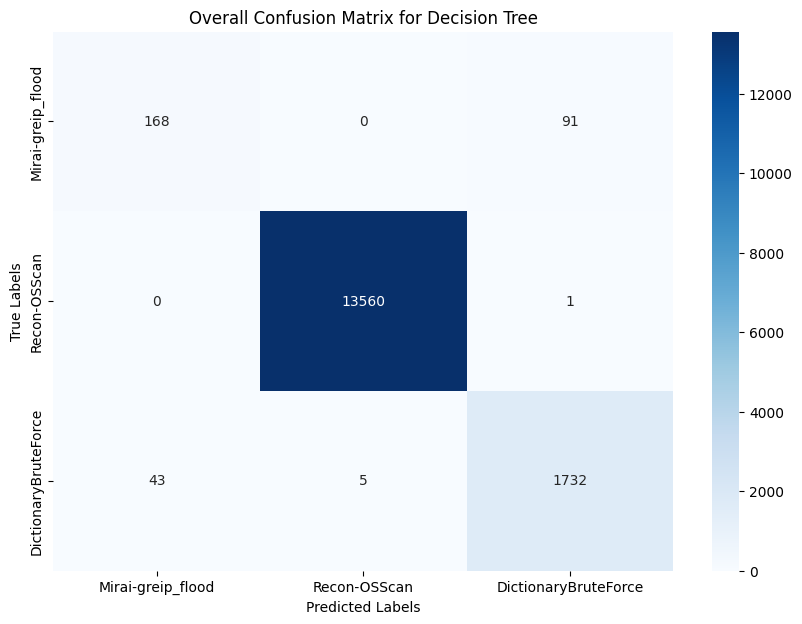

Precision per class for Decision Tree: [0.89005236 0.99970512 0.95173536]
Recall per class for Decision Tree: [0.65637066 1.         0.98595506]
F1 Score per class for Decision Tree: [0.75555556 0.99985254 0.96854305]
AUC-ROC Score for Decision Tree: 0.9947279429302536
Feature Importances for Decision Tree:
                                               Feature  Importance
14                                                Min    0.792194
25                                     Weight_z_score    0.088866
19                                                IAT    0.077488
39      Binned_Equi_Depth_Protocol_Type_(12.6, 43.21]    0.018621
20                                             Number    0.010258
23                                         Covariance    0.002555
9                                           rst_count    0.002347
0                                                Rate    0.001916
8                                           urg_count    0.001796
3                             

In [ ]:
# Define hyperparameters for Decision Tree tuning
param_grid_dt = {
    'max_depth': [5, 10, 15, None],           # Limit depth to avoid overfitting
    'min_samples_split': [2, 5, 10],          # Control the number of samples needed for splits
    'min_samples_leaf': [1, 2, 4, 6],         # Minimum number of samples at a leaf node
    'class_weight': ['balanced', None]        # Check if class weighting improves performance on imbalanced data
}

# Initialize GridSearchCV with StratifiedKFold cross-validation
skf_dt = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=skf_dt, scoring='f1_macro')

# Fit GridSearchCV on the data
grid_search_dt.fit(X, y)

# Get the best parameters from GridSearchCV
print("Best Parameters for Decision Tree:", grid_search_dt.best_params_)

# After finding the best parameters, fit the final model
best_dt_model = grid_search_dt.best_estimator_

# Store cross-validation scores
cv_scores_dt = []

# Store confusion matrices for each fold
confusion_matrices_dt = []

# Stratified K-Fold Cross-Validation
for train_index, val_index in skf_dt.split(X, y):
    X_train_cv, X_val_cv = X.iloc[train_index], X.iloc[val_index]
    y_train_cv, y_val_cv = y.iloc[train_index], y.iloc[val_index]

    # Fit the model on the training set for each class
    best_dt_model.fit(X_train_cv, y_train_cv)

    # Make predictions on the validation set
    y_pred_dt = best_dt_model.predict(X_val_cv)

    # Calculate F1 Score for each fold
    f1_dt = f1_score(y_val_cv, y_pred_dt, average='macro')
    cv_scores_dt.append(f1_dt)

    # Confusion Matrix
    cm_dt = confusion_matrix(y_val_cv, y_pred_dt)
    confusion_matrices_dt.append(cm_dt)

# Print the cross-validation scores and mean F1 score
print(f'Cross-Validation F1 Scores for Decision Tree: {cv_scores_dt}')
print(f'Mean CV F1 Score for Decision Tree: {sum(cv_scores_dt) / len(cv_scores_dt)}')

# Print overall confusion matrix
overall_confusion_matrix_dt = sum(confusion_matrices_dt)
print(f'Overall Confusion Matrix for Decision Tree:\n{overall_confusion_matrix_dt}')
# Define the labels (you can modify this based on your dataset)
labels = ['Mirai-greip_flood', 'Recon-OSScan', 'DictionaryBruteForce']

# Create a heatmap for the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(overall_confusion_matrix_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Overall Confusion Matrix for Decision Tree')
plt.show()

# Calculate and print evaluation metrics
precision_dt = precision_score(y, best_dt_model.predict(X), average=None)  # Per-class precision
recall_dt = recall_score(y, best_dt_model.predict(X), average=None)        # Per-class recall
f1_dt = f1_score(y, best_dt_model.predict(X), average=None)                # Per-class F1-score

print(f'Precision per class for Decision Tree: {precision_dt}')
print(f'Recall per class for Decision Tree: {recall_dt}')
print(f'F1 Score per class for Decision Tree: {f1_dt}')

# Calculate AUC-ROC for each class if using a multi-class method
# Note: DecisionTreeClassifier does not support predict_proba by default, unless you set `class_weight='balanced'`
if hasattr(best_dt_model, "predict_proba"):
    y_prob_dt = best_dt_model.predict_proba(X)
    roc_auc_dt = roc_auc_score(y, y_prob_dt, multi_class='ovr')
    print(f'AUC-ROC Score for Decision Tree: {roc_auc_dt}')
else:
    print("AUC-ROC cannot be calculated as the model does not support probability predictions.")

# Feature Importance
importances_dt = best_dt_model.feature_importances_
feature_importance_dt_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances_dt})
feature_importance_dt_df = feature_importance_dt_df.sort_values(by='Importance', ascending=False)

print("Feature Importances for Decision Tree:\n", feature_importance_dt_df)


In [ ]:
# Perform one-hot encoding
df_encoded = pd.get_dummies(dataset_2, columns=['label'], dtype='int')
df_encoded.to_csv('encoded_dataset.csv', index=False)

# Define features and target variable
X = df_encoded.drop(columns=['label_Mirai-greip_flood', 'label_Recon-OSScan', 'label_DictionaryBruteForce'])
y = df_encoded[['label_Mirai-greip_flood', 'label_Recon-OSScan', 'label_DictionaryBruteForce']].idxmax(axis=1)

#Preprocessing the data for SVM, KNN and MLP Classifiers
# Continuous and Categorical Features
continuous_features = [
    'flow_duration', 'Header_Length','Protocol Type', 'Duration', 'Rate',
    'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count',
    'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number',
    'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight'
]

categorical_features = ['syn_flag_number', 'rst_flag_number', 'psh_flag_number','ack_flag_number', 'HTTPS', 'TCP', 'UDP']

# Define the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), continuous_features),
        ('onehot', OneHotEncoder(), categorical_features)
    ]
)



## **SVM CLASSIFIER**

In [ ]:
# Create the full pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42))
])


param_grid_svm_poly = {
    'classifier__C': [0.01,0.1, 1, 10],    # Regularization parameter for SVC
    'classifier__kernel': ['rbf','linear'],             # Specify polynomial kernel
    'classifier__class_weight': ['balanced'],   # Handle class imbalance
    'classifier__gamma': [1e-4, 1e-3, 1e-2, 0.1, 1]          # Includes low values to control kernel influence
}



# Initialize GridSearchCV with StratifiedKFold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search_svm = GridSearchCV(pipeline, param_grid_svm_poly, cv=skf, scoring='f1_macro')

# Fit GridSearchCV on the data
grid_search_svm.fit(X, y)


# Get the best parameters from GridSearchCV
print("Best Parameters for SVM:", grid_search_svm.best_params_)

# After finding the best parameters, fit the final model
best_svm_model = grid_search_svm.best_estimator_

# Store cross-validation scores
cv_scores_svm = []

# Store confusion matrices for each fold
confusion_matrices_svm = []

# Stratified K-Fold Cross-Validation
for train_index, val_index in skf.split(X, y):
    X_train_cv, X_val_cv = X.iloc[train_index], X.iloc[val_index]
    y_train_cv, y_val_cv = y.iloc[train_index], y.iloc[val_index]

    # Fit the model on the training set for each fold
    best_svm_model.fit(X_train_cv, y_train_cv)

    # Make predictions on the validation set
    y_pred_svm = best_svm_model.predict(X_val_cv)

    # Calculate F1 Score for each fold
    f1_svm = f1_score(y_val_cv, y_pred_svm, average='macro')
    cv_scores_svm.append(f1_svm)

    # Confusion Matrix
    cm_svm = confusion_matrix(y_val_cv, y_pred_svm)
    confusion_matrices_svm.append(cm_svm)

# Print the cross-validation scores and mean F1 score
print(f'Cross-Validation F1 Scores for SVM: {cv_scores_svm}')
print(f'Mean CV F1 Score for SVM: {sum(cv_scores_svm) / len(cv_scores_svm)}')

# Print overall confusion matrix
overall_confusion_matrix_svm = sum(confusion_matrices_svm)
print(f'Overall Confusion Matrix for SVM:\n{overall_confusion_matrix_svm}')

# Define the labels
labels = ['Mirai-greip_flood', 'Recon-OSScan', 'DictionaryBruteForce']

# Create a heatmap for the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(overall_confusion_matrix_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Overall Confusion Matrix for SVM')
plt.show()

# Calculate and print evaluation metrics
precision_svm = precision_score(y, best_svm_model.predict(X), average=None)  # Per-class precision
recall_svm = recall_score(y, best_svm_model.predict(X), average=None)        # Per-class recall
f1_svm = f1_score(y, best_svm_model.predict(X), average=None)                # Per-class F1-score

print(f'Precision per class for SVM: {precision_svm}')
print(f'Recall per class for SVM: {recall_svm}')
print(f'F1 Score per class for SVM: {f1_svm}')

# Feature Importance (For linear kernel)
if grid_search_svm.best_params_['classifier__kernel'] == 'linear':
    coefs_svm = best_svm_model.named_steps['classifier'].coef_.flatten()
    feature_importance_svm_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefs_svm})
    feature_importance_svm_df = feature_importance_svm_df.sort_values(by='Coefficient', ascending=False)
    print("Feature Importances for Linear SVM:\n", feature_importance_svm_df)
else:
    print("Feature importance analysis is only applicable to linear SVMs.")

Cross-Validation F1 Scores for SVM: [0.7880272166903916, 0.7832709515833992, 0.7664626161753074, 0.7322996213841937, 0.791388913092767]
Mean CV F1 Score for SVM: 0.7722898637852118
Overall Confusion Matrix for SVM:
[[  168     0    91]
 [    0 13555     6]
 [  329     1  1450]]


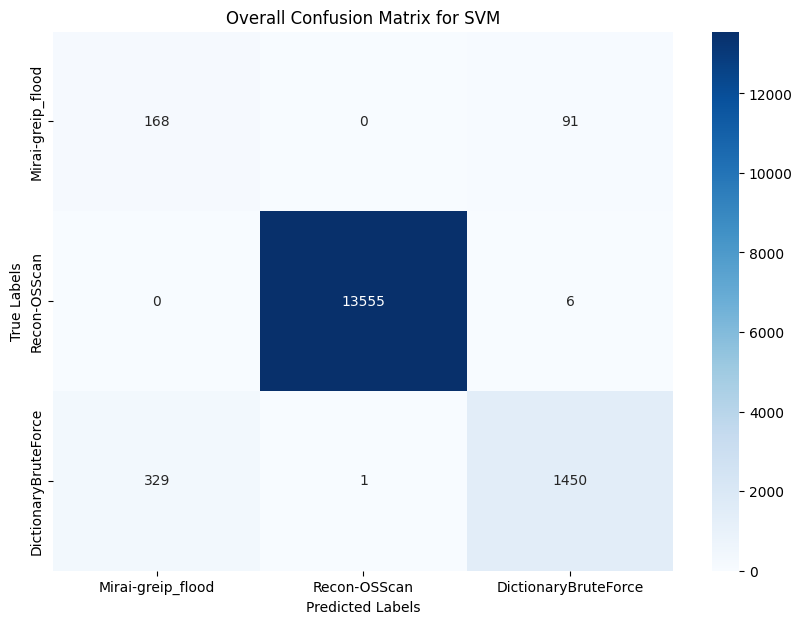

Precision per class for SVM: [0.45351044 1.         0.98612029]
Recall per class for SVM: [0.92277992 0.99992626 0.83820225]
F1 Score per class for SVM: [0.60814249 0.99996313 0.90616459]
Feature importance analysis is only applicable to linear SVMs.


In [ ]:
# After finding the best parameters, fit the final model
best_svm_model = grid_search_svm.best_estimator_

# Store cross-validation scores
cv_scores_svm = []

# Store confusion matrices for each fold
confusion_matrices_svm = []

# Stratified K-Fold Cross-Validation
for train_index, val_index in skf.split(X, y):
    X_train_cv, X_val_cv = X.iloc[train_index], X.iloc[val_index]
    y_train_cv, y_val_cv = y.iloc[train_index], y.iloc[val_index]

    # Fit the model on the training set for each fold
    best_svm_model.fit(X_train_cv, y_train_cv)

    # Make predictions on the validation set
    y_pred_svm = best_svm_model.predict(X_val_cv)

    # Calculate F1 Score for each fold
    f1_svm = f1_score(y_val_cv, y_pred_svm, average='macro')
    cv_scores_svm.append(f1_svm)

    # Confusion Matrix
    cm_svm = confusion_matrix(y_val_cv, y_pred_svm)
    confusion_matrices_svm.append(cm_svm)

# Print the cross-validation scores and mean F1 score
print(f'Cross-Validation F1 Scores for SVM: {cv_scores_svm}')
print(f'Mean CV F1 Score for SVM: {sum(cv_scores_svm) / len(cv_scores_svm)}')

# Print overall confusion matrix
overall_confusion_matrix_svm = sum(confusion_matrices_svm)
print(f'Overall Confusion Matrix for SVM:\n{overall_confusion_matrix_svm}')

# Define the labels
labels = ['Mirai-greip_flood', 'Recon-OSScan', 'DictionaryBruteForce']

# Create a heatmap for the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(overall_confusion_matrix_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Overall Confusion Matrix for SVM')
plt.show()

# Calculate and print evaluation metrics
precision_svm = precision_score(y, best_svm_model.predict(X), average=None)  # Per-class precision
recall_svm = recall_score(y, best_svm_model.predict(X), average=None)        # Per-class recall
f1_svm = f1_score(y, best_svm_model.predict(X), average=None)                # Per-class F1-score

print(f'Precision per class for SVM: {precision_svm}')
print(f'Recall per class for SVM: {recall_svm}')
print(f'F1 Score per class for SVM: {f1_svm}')

# Feature Importance (For linear kernel)
if grid_search_svm.best_params_['classifier__kernel'] == 'linear':
    coefs_svm = best_svm_model.named_steps['classifier'].coef_.flatten()
    feature_importance_svm_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefs_svm})
    feature_importance_svm_df = feature_importance_svm_df.sort_values(by='Coefficient', ascending=False)
    print("Feature Importances for Linear SVM:\n", feature_importance_svm_df)
else:
    print("Feature importance analysis is only applicable to linear SVMs.")

## **KNN CLASSIFIER**

Cross-Validation F1 Scores for KNN with SMOTE: [0.7291357243148044, 0.7151609894510825, 0.7347184263453371, 0.7080768232172104, 0.7250286046303746]
Mean CV F1 Score for KNN with SMOTE: 0.7224241135917618
Overall Confusion Matrix for KNN with SMOTE:
[[13553     7     1]
 [    3  1241   536]
 [    0    79   180]]


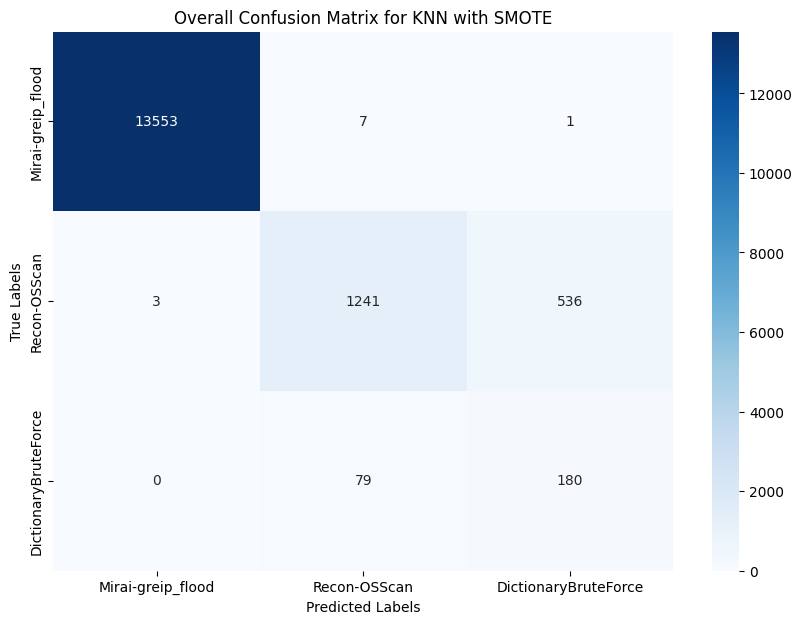

Precision per class for KNN with SMOTE: [0.99992626 0.99109264 0.69014085]
Recall per class for KNN with SMOTE: [0.99992626 0.93764045 0.94594595]
F1 Score per class for KNN with SMOTE: [0.99992626 0.96362587 0.7980456 ]


In [ ]:
# Define the parameter grid for KNN
param_grid_knn = {
    'classifier__n_neighbors': [3, 5, 7, 9],          # Number of neighbors to consider
    'classifier__weights': ['uniform', 'distance'],   # Weight by distance to prioritize closer neighbors
    'classifier__metric' : ['euclidean', 'manhattan'] # Metric
}

# Map string labels to numeric labels
label_mapping = {'label_Mirai-greip_flood': 0, 'label_Recon-OSScan': 1, 'label_DictionaryBruteForce': 2}
y = y.map(label_mapping)

# Create the KNN pipeline
pipeline_knn_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(sampling_strategy='minority', random_state=42)),
    ('classifier', KNeighborsClassifier())
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize GridSearchCV for KNN with SMOTE
grid_search_knn_smote = GridSearchCV(
    pipeline_knn_smote,
    param_grid_knn,
    cv=skf,
    scoring='f1_macro'
)

# Fit GridSearchCV on the data with SMOTE
grid_search_knn_smote.fit(X, y)

# Fit the final KNN model with SMOTE on the best parameters
best_knn_smote_model = grid_search_knn_smote.best_estimator_

# Initialize lists for cross-validation scores and confusion matrices
cv_scores_knn_smote = []
confusion_matrices_knn_smote = []

# Stratified K-Fold Cross-Validation for KNN with SMOTE
for train_index, val_index in skf.split(X, y):
    # Split data for this fold
    X_train_cv, X_val_cv = X.iloc[train_index], X.iloc[val_index]
    y_train_cv, y_val_cv = y.iloc[train_index], y.iloc[val_index]

    # Fit the best KNN model on the training set for each fold
    best_knn_smote_model.fit(X_train_cv, y_train_cv)

    # Make predictions on the validation set
    y_pred_knn_smote = best_knn_smote_model.predict(X_val_cv)

    # Calculate F1 Score for each fold
    f1_knn_smote = f1_score(y_val_cv, y_pred_knn_smote, average='macro')
    cv_scores_knn_smote.append(f1_knn_smote)

    # Compute confusion matrix for this fold
    cm_knn_smote = confusion_matrix(y_val_cv, y_pred_knn_smote)
    confusion_matrices_knn_smote.append(cm_knn_smote)

# Print cross-validation scores and mean F1 score
print(f'Cross-Validation F1 Scores for KNN with SMOTE: {cv_scores_knn_smote}')
print(f'Mean CV F1 Score for KNN with SMOTE: {sum(cv_scores_knn_smote) / len(cv_scores_knn_smote)}')

# Compute the overall confusion matrix by summing across all folds
overall_confusion_matrix_knn_smote = sum(confusion_matrices_knn_smote)
print(f'Overall Confusion Matrix for KNN with SMOTE:\n{overall_confusion_matrix_knn_smote}')

# Define the labels
labels = ['Mirai-greip_flood', 'Recon-OSScan', 'DictionaryBruteForce']

# Create a heatmap for the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(overall_confusion_matrix_knn_smote, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Overall Confusion Matrix for KNN with SMOTE')
plt.show()

# Calculate and print evaluation metrics (precision, recall, F1 per class)
precision_knn_smote = precision_score(y, best_knn_smote_model.predict(X), average=None)
recall_knn_smote = recall_score(y, best_knn_smote_model.predict(X), average=None)
f1_knn_smote = f1_score(y, best_knn_smote_model.predict(X), average=None)

print(f'Precision per class for KNN with SMOTE: {precision_knn_smote}')
print(f'Recall per class for KNN with SMOTE: {recall_knn_smote}')
print(f'F1 Score per class for KNN with SMOTE: {f1_knn_smote}')


## **MLP**

Best Parameters for MLP with SMOTE: {'classifier__activation': 'relu', 'classifier__alpha': 0.0001, 'classifier__batch_size': 64, 'classifier__early_stopping': True, 'classifier__hidden_layer_sizes': (150,), 'classifier__learning_rate_init': 0.001, 'classifier__max_iter': 300}
Cross-Validation F1 Scores for MLP with SMOTE: [0.8052623941579502, 0.7913330947060492, 0.7768238301920447, 0.7822198436190392, 0.8068040442927257]
Mean CV F1 Score for MLP with SMOTE: 0.7924886413935617
Overall Confusion Matrix for MLP with SMOTE:
[[  150     0   109]
 [    0 13556     5]
 [  220     3  1557]]


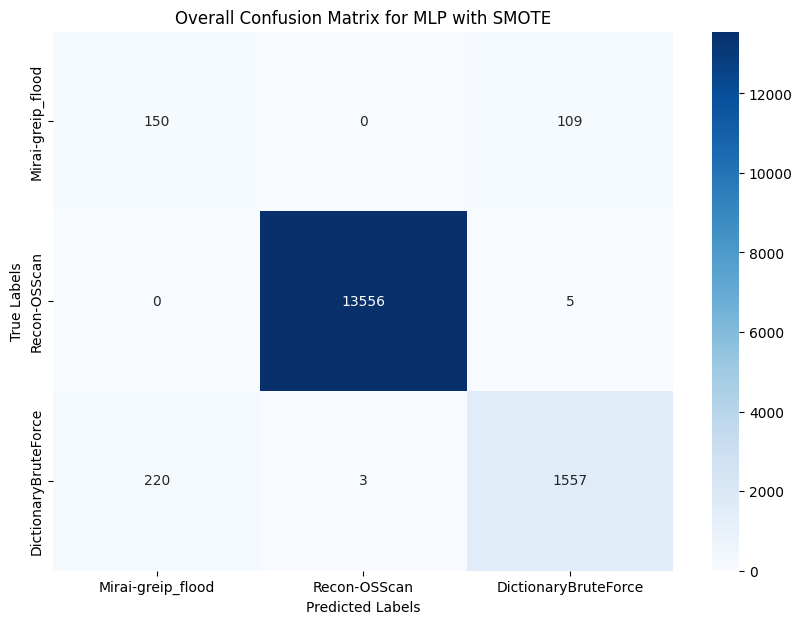

Precision per class for MLP with SMOTE: [0.58937198 0.99985252 0.98953846]
Recall per class for MLP with SMOTE: [0.94208494 0.99985252 0.90337079]
F1 Score per class for MLP with SMOTE: [0.72511144 0.99985252 0.94449339]


In [ ]:
# Define pipeline with SMOTE and MLP
pipeline_mlp_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(sampling_strategy='minority', random_state=42)),
    ('classifier', MLPClassifier(max_iter=200, random_state=42))
])

param_grid_mlp = {
    'classifier__hidden_layer_sizes': [(100,), (150,), (100, 50)],
    'classifier__activation': ['relu'],
    'classifier__learning_rate_init': [0.0001, 0.001],
    'classifier__max_iter': [300],
    'classifier__alpha': [0.0001, 0.001],
    'classifier__early_stopping': [True],
    'classifier__batch_size': [64]
}

# Stratified K-Fold cross-validator
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize GridSearchCV
grid_search_mlp_smote = GridSearchCV(
    pipeline_mlp_smote,
    param_grid_mlp,
    cv=skf,
    scoring='f1_macro'
)


# Fit GridSearchCV on the data
grid_search_mlp_smote.fit(X, y)

# Get the best parameters and model
print("Best Parameters for MLP with SMOTE:", grid_search_mlp_smote.best_params_)
best_mlp_model_smote = grid_search_mlp_smote.best_estimator_

# Store cross-validation scores and confusion matrices
cv_scores_mlp_smote = []
confusion_matrices_mlp_smote = []

# Cross-validation with the best model
for train_index, val_index in skf.split(X, y):
    X_train_cv, X_val_cv = X.iloc[train_index], X.iloc[val_index]
    y_train_cv, y_val_cv = y.iloc[train_index], y.iloc[val_index]

    # Fit the best model on training data for each fold
    best_mlp_model_smote.fit(X_train_cv, y_train_cv)

    # Predict on validation data
    y_pred_mlp = best_mlp_model_smote.predict(X_val_cv)

    # Calculate F1 score
    f1_mlp = f1_score(y_val_cv, y_pred_mlp, average='macro')
    cv_scores_mlp_smote.append(f1_mlp)

    # Confusion matrix
    cm_mlp = confusion_matrix(y_val_cv, y_pred_mlp)
    confusion_matrices_mlp_smote.append(cm_mlp)

# Print cross-validation scores and mean F1 score
print(f'Cross-Validation F1 Scores for MLP with SMOTE: {cv_scores_mlp_smote}')
print(f'Mean CV F1 Score for MLP with SMOTE: {sum(cv_scores_mlp_smote) / len(cv_scores_mlp_smote)}')

# Calculate the overall confusion matrix
overall_confusion_matrix_mlp_smote = sum(confusion_matrices_mlp_smote)
print(f'Overall Confusion Matrix for MLP with SMOTE:\n{overall_confusion_matrix_mlp_smote}')

# Define class labels
labels = ['Mirai-greip_flood', 'Recon-OSScan', 'DictionaryBruteForce']

# Create a heatmap for the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(overall_confusion_matrix_mlp_smote, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Overall Confusion Matrix for MLP with SMOTE')
plt.show()

# Calculate and print evaluation metrics
precision_mlp = precision_score(y, best_mlp_model_smote.predict(X), average=None)
recall_mlp = recall_score(y, best_mlp_model_smote.predict(X), average=None)
f1_mlp = f1_score(y, best_mlp_model_smote.predict(X), average=None)

print(f'Precision per class for MLP with SMOTE: {precision_mlp}')
print(f'Recall per class for MLP with SMOTE: {recall_mlp}')
print(f'F1 Score per class for MLP with SMOTE: {f1_mlp}')

## **Unknown Dataset**

In [ ]:
test = pd.read_csv('unknowndataset.csv')
print(dataset.shape)
dataset.describe()
print(dataset.dtypes)
missing_values = dataset.isnull().sum()
print("Missing values in each column:\n", missing_values)

(15600, 48)
Unnamed: 0           int64
flow_duration      float64
Header_Length      float64
Protocol Type      float64
Duration           float64
Rate               float64
Srate              float64
Drate              float64
fin_flag_number      int64
syn_flag_number      int64
rst_flag_number      int64
psh_flag_number      int64
ack_flag_number      int64
ece_flag_number      int64
cwr_flag_number      int64
ack_count          float64
syn_count          float64
fin_count          float64
urg_count          float64
rst_count          float64
HTTP                 int64
HTTPS                int64
DNS                  int64
Telnet               int64
SMTP                 int64
SSH                  int64
IRC                  int64
TCP                  int64
UDP                  int64
DHCP                 int64
ARP                  int64
ICMP                 int64
IPv                  int64
LLC                  int64
Tot sum            float64
Min                float64
Max             

In [ ]:
new_test = test.drop(['Unnamed: 0','Drate','Srate','fin_flag_number', 'ece_flag_number', 'cwr_flag_number', 'Telnet', 'SMTP', 'IRC','DNS', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'HTTP', 'SSH'], axis=1) #Removing the mentioned columns as they are not necessary


## **Preprocessing on Unknown Dataset**

In [ ]:
# Select the column of interest, e.g., 'Duration'
data = new_test['Duration']

# Calculating number of bins using Doane's Rule
skewness = skew(data)     # Calculate skewness of the dataset
n = len(data)             # Number of data points
sigma_g = np.sqrt(6 / n)  # Standard error of skewness
num_bins_doane = int(1 + np.log2(n) + np.log2(1 + (skewness / sigma_g)))  # Doane's Rule
print(f"Number of bins (Doane's Rule): {num_bins_doane}")

# Calculating number of bins using Sturges' Rule
def sturges_rule(data):
    n = len(data)
    return int(np.ceil(np.log2(n) + 1))  # Sturges' Rule

num_bins_sturges = sturges_rule(data)
print(f"Number of bins (Sturges' Rule): {num_bins_sturges}")


num_bins_depth = 13 #number of bins for Equi Depth Binning

new_test['Binned_Equi_Depth_Duration'] = pd.qcut(data, q=num_bins_depth,duplicates='drop')


print(new_test[['Duration', 'Binned_Equi_Depth_Duration']].sort_values('Duration'))

freq_equi_depth = new_test[['Duration', 'Binned_Equi_Depth_Duration']].sort_values('Duration').groupby('Binned_Equi_Depth_Duration',observed=True).count()
print(new_test[['Duration', 'Binned_Equi_Depth_Duration']].sort_values('Duration').groupby('Binned_Equi_Depth_Duration', observed=True).count())



Number of bins (Doane's Rule): 19
Number of bins (Sturges' Rule): 13
      Duration   Binned_Equi_Depth_Duration
3722       1.8  (1.7990000000000002, 63.13]
3449      36.8  (1.7990000000000002, 63.13]
210       39.4  (1.7990000000000002, 63.13]
3183      42.6  (1.7990000000000002, 63.13]
341       43.4  (1.7990000000000002, 63.13]
...        ...                          ...
1978     255.0                (87.6, 255.0]
2094     255.0                (87.6, 255.0]
1217     255.0                (87.6, 255.0]
3780     255.0                (87.6, 255.0]
2497     255.0                (87.6, 255.0]

[3901 rows x 2 columns]
                             Duration
Binned_Equi_Depth_Duration           
(1.7990000000000002, 63.13]       304
(63.13, 63.36]                    333
(63.36, 64.0]                    1780
(64.0, 65.28]                     292
(65.28, 65.91]                    313
(65.91, 69.18]                    279
(69.18, 87.6]                     299
(87.6, 255.0]                     30

In [ ]:
# Select the column of interest, e.g., 'Protocol Type'
data = new_test['Protocol Type']


#Equi-Width and Equi-Depth Binning Technique for Protocol Type
num_bins_depth = 13
new_test['Binned_Equi_Depth_Protocol_Type'] = pd.qcut(data, q=num_bins_depth,duplicates='drop')

print(new_test[['Protocol Type', 'Binned_Equi_Depth_Protocol_Type']].sort_values('Protocol Type'))

freq_equi_depth = new_test[['Protocol Type', 'Binned_Equi_Depth_Protocol_Type']].sort_values('Protocol Type').groupby('Binned_Equi_Depth_Protocol_Type',observed=True).count()

print(new_test[['Protocol Type', 'Binned_Equi_Depth_Protocol_Type']].sort_values('Protocol Type').groupby('Binned_Equi_Depth_Protocol_Type', observed=True).count())


      Protocol Type Binned_Equi_Depth_Protocol_Type
3449            3.6                    (3.599, 7.1]
483             4.3                    (3.599, 7.1]
2983            4.8                    (3.599, 7.1]
2823            4.8                    (3.599, 7.1]
2031            4.8                    (3.599, 7.1]
...             ...                             ...
1926           47.0                   (46.59, 47.0]
1922           47.0                   (46.59, 47.0]
1919           47.0                   (46.59, 47.0]
2002           47.0                   (46.59, 47.0]
3900           47.0                   (46.59, 47.0]

[3901 rows x 2 columns]
                                 Protocol Type
Binned_Equi_Depth_Protocol_Type               
(3.599, 7.1]                               353
(7.1, 38.18]                               248
(38.18, 44.43]                             300
(44.43, 45.59]                             300
(45.59, 46.07]                             319
(46.07, 46.29]        

In [ ]:
#Normalizing Weight Z-Score Normalization Techniques

df = pd.DataFrame(new_test.Weight)

# Z-Score Normalization using sklearn
standard_scaler = StandardScaler()
new_test['Weight_z_score'] = standard_scaler.fit_transform(df[['Weight']])

# Print the DataFrame with normalized values
print(df)

df = pd.DataFrame(new_test.flow_duration)
new_test['flow_duration_category'] = np.select( [df['flow_duration'].between(0, 1,inclusive='both'),
                                           df['flow_duration'].between(1,10000, inclusive='neither'),
                                           df['flow_duration'].between(10000,np.inf, inclusive='left')],['Small', 'Medium', 'Large'] )

# Calculate the frequency of each category
category_frequencies = new_test['flow_duration_category'].value_counts().sort_index()

print(df)
print(category_frequencies)

df = pd.DataFrame(new_test.Header_Length)
median_threshold = df['Header_Length'].median()
binarizer_median = Binarizer(threshold=median_threshold)

# Apply binarization to the 'Header_Length' column and add the result to a new column
new_test['Header_Length_Binarized'] = binarizer_median.fit_transform(df[['Header_Length']])

# Print the DataFrame with the binarized values
print(df)

      Weight
0     141.55
1     141.55
2     141.55
3     141.55
4     141.55
...      ...
3896  141.55
3897  141.55
3898  141.55
3899  141.55
3900  141.55

[3901 rows x 1 columns]
      flow_duration
0          0.000000
1          0.002190
2          0.001110
3          0.031130
4          0.000387
...             ...
3896       0.000000
3897       0.001985
3898       0.131170
3899       0.020118
3900       0.000000

[3901 rows x 1 columns]
flow_duration_category
Large        5
Medium     438
Small     3458
Name: count, dtype: int64
      Header_Length
0              0.00
1              4.78
2              1.59
3             26.74
4              1.16
...             ...
3896           0.00
3897           3.38
3898         133.20
3899           1.48
3900           0.00

[3901 rows x 1 columns]


## **Making Prediction on unknown dataset**

In [ ]:
# Add missing columns with zeros
for col in X.columns:
    if col not in new_test.columns:
        new_test[col] = 0

# Remove any extra columns not present in the training set
new_test = new_test[X.columns]

# Step 3: Make predictions
predictions = best_model_random_forest.predict(new_test)

# Step 5: Create a DataFrame for the results
results = pd.DataFrame(predictions, columns=['Predicted_Class'])

# Step 6: Save the results to a CSV file
results.to_csv('predictions_results.csv', index=False)

# Optional: Print the results
print(results.head())

           Predicted_Class
0  label_Mirai-greip_flood
1  label_Mirai-greip_flood
2  label_Mirai-greip_flood
3  label_Mirai-greip_flood
4  label_Mirai-greip_flood
